# MINDS-14: классификация intent по тексту и аудио



In [11]:
%pip install -q "accelerate>=0.30.0" "datasets[audio]>=2.19.0" "evaluate>=0.4.2" "fastapi>=0.111.0" "jiwer>=3.0.4" "joblib>=1.4.0" "loguru>=0.7.2" "numpy>=1.26.0" "pandas>=2.2.0" "peft>=0.11.0" "pydantic-settings>=2.2.0" "python-multipart>=0.0.9" "scikit-learn>=1.4.0" "scipy>=1.11.0" "soundfile>=0.12.1" "torch>=2.2.0" "transformers>=4.41.0" "uvicorn[standard]>=0.29.0"

Note: you may need to restart the kernel to use updated packages.


In [12]:
import warnings
warnings.filterwarnings("ignore")

from __future__ import annotations

import random
import sys
from pathlib import Path
from typing import Any

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import Dataset, DatasetDict, load_dataset
from IPython.display import display
from jiwer import cer, wer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import FeatureUnion, Pipeline

PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / "src").exists():
    sys.path.append(str(PROJECT_ROOT / "src"))

RANDOM_STATE = 42
DATASET_NAME = "PolyAI/minds14"
LANGUAGE_CONFIG = "ru-RU"
TEST_SIZE = 0.20
ASR_MODEL_NAME = "openai/whisper-small"
ASR_LANGUAGE = "russian"
ASR_TASK = "transcribe"
ASR_EVAL_LIMIT: int | None = None
MODEL_PATH = Path("models/intent_classifier.joblib")

THRESHOLDS = {
    "recall_weighted": 0.70,
    "precision_weighted": 0.75,
    "f1_weighted": 0.80,
}

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

## 1. Загрузка данных

В датасете для этой постановки нет отдельной тестовой выборки, поэтому используется стандартный holdout split: 80% train и 20% test.

20% на test - компромисс между стабильной оценкой многоклассовой модели и сохранением большей части данных для обучения. Параметр `stratify` сохраняет пропорции `intent_class` в train и test.

In [13]:
def load_labeled_split(dataset_name: str, language_config: str) -> Dataset:
    """Загружает размеченный сплит из выбранной конфигурации MINDS-14."""
    raw = load_dataset(dataset_name, language_config)
    if isinstance(raw, DatasetDict):
        if "train" in raw:
            return raw["train"]
        return raw[next(iter(raw.keys()))]
    return raw


def first_existing(columns: list[str], candidates: list[str]) -> str | None:
    """Возвращает первый столбец-кандидат, который есть в схеме датасета."""
    column_set = set(columns)
    for candidate in candidates:
        if candidate in column_set:
            return candidate
    return None


base_ds = load_labeled_split(DATASET_NAME, LANGUAGE_CONFIG)
print(base_ds)
print("Columns:", base_ds.column_names)
print("Features:", base_ds.features)

text_col = first_existing(base_ds.column_names, ["transcription", "text", "utterance", "sentence", "transcript"])
label_col = first_existing(base_ds.column_names, ["intent_class", "label", "intent"])
audio_col = first_existing(base_ds.column_names, ["audio", "speech"])

assert text_col is not None, f"Не найдена текстовая колонка. Доступные: {base_ds.column_names}"
assert label_col is not None, f"Не найдена колонка intent. Доступные: {base_ds.column_names}"
assert audio_col is not None, f"Не найдена аудио-колонка. Доступные: {base_ds.column_names}"

print({"text_col": text_col, "label_col": label_col, "audio_col": audio_col})

Dataset({
    features: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id'],
    num_rows: 539
})
Columns: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id']
Features: {'path': Value('string'), 'audio': Audio(sampling_rate=8000, decode=True, num_channels=None, stream_index=None), 'transcription': Value('string'), 'english_transcription': Value('string'), 'intent_class': ClassLabel(names=['abroad', 'address', 'app_error', 'atm_limit', 'balance', 'business_loan', 'card_issues', 'cash_deposit', 'direct_debit', 'freeze', 'high_value_payment', 'joint_account', 'latest_transactions', 'pay_bill']), 'lang_id': ClassLabel(names=['cs-CZ', 'de-DE', 'en-AU', 'en-GB', 'en-US', 'es-ES', 'fr-FR', 'it-IT', 'ko-KR', 'nl-NL', 'pl-PL', 'pt-PT', 'ru-RU', 'zh-CN'])}
{'text_col': 'transcription', 'label_col': 'intent_class', 'audio_col': 'audio'}


In [14]:
def get_label_names(dataset: Dataset, label_column: str) -> dict[int, str] | None:
    """Сопоставляет числовые id меток с читаемыми названиями интентов при наличии метаданных."""
    feature = dataset.features[label_column]
    names = getattr(feature, "names", None)
    if names:
        return {idx: name for idx, name in enumerate(names)}
    return None


label_names = get_label_names(base_ds, label_col)

df = base_ds.select_columns([text_col, label_col]).to_pandas()
df["source_index"] = np.arange(len(df))
df = df.dropna().reset_index(drop=True)

if label_names is not None:
    df[label_col] = df[label_col].map(lambda value: label_names[int(value)])
else:
    df[label_col] = df[label_col].astype(str)

df[text_col] = df[text_col].astype(str).str.strip()
df = df[df[text_col].str.len() > 0].reset_index(drop=True)

print("Размер датасета:", len(df))
print("Число классов:", df[label_col].nunique())
display(df.head())

Размер датасета: 539
Число классов: 14


,transcription,intent_class,source_index
0,Здравствуйте я бы хотела пересмотреть свои пре...,latest_transactions,0
1,Покажи мне мои последние транзакции если платё...,latest_transactions,1
2,покажите мне мои последние последние транзакции,latest_transactions,2
3,Покажи мне информацию о всех моих платежах за ...,latest_transactions,3
4,Я хочу узнать свои последние транзакции за сег...,latest_transactions,4


## 2. Баланс классов

Баланс классов нужно смотреть до обучения. Если один intent встречается заметно чаще других, accuracy может быть завышенной, а редкие классы могут деградировать.

`weighted F1` считаем дополнительно: в реальной банковской задаче частые intent-классы дают больше обращений и сильнее влияют на пользовательский опыт. При этом `macro F1` и отчет по классам нужны, чтобы не потерять качество на редких или бизнес-критичных intent.

,count,share_%
intent_class,,
cash_deposit,46,8.53
balance,42,7.79
business_loan,41,7.61
card_issues,40,7.42
joint_account,40,7.42
address,40,7.42
pay_bill,39,7.24
atm_limit,37,6.86
freeze,37,6.86


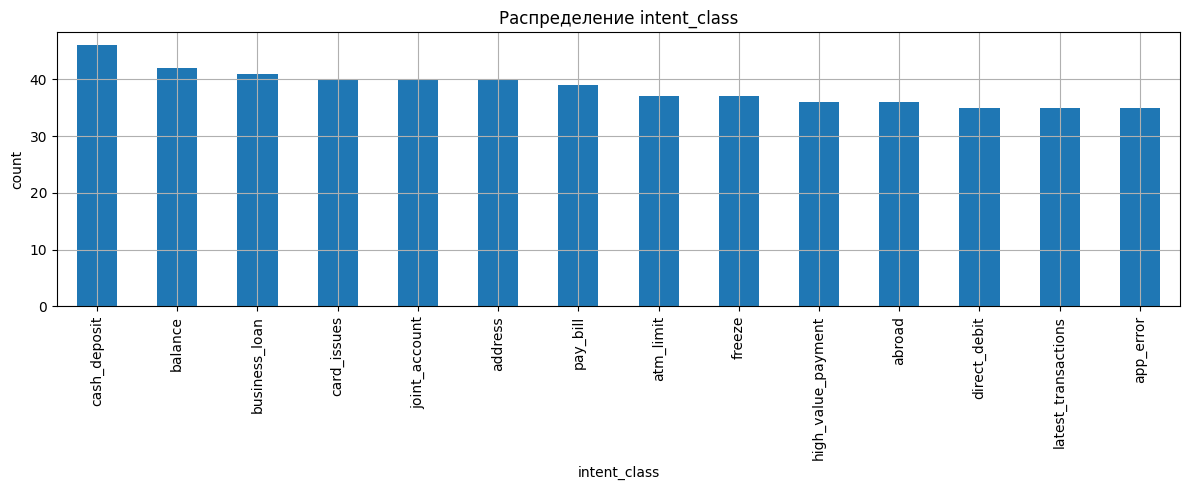

In [15]:
class_counts = df[label_col].value_counts().sort_values(ascending=False)
balance = pd.DataFrame(
    {
        "count": class_counts,
        "share_%": (class_counts / class_counts.sum() * 100).round(2),
    }
)
display(balance)

ax = class_counts.plot(kind="bar")
ax.set_title("Распределение intent_class")
ax.set_xlabel("intent_class")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

Отношение max/min: 1.31x
Потенциально бизнес-критичные классы по названию: ['cash_deposit', 'card_issues', 'freeze', 'high_value_payment', 'latest_transactions']
Вывод: сильного дисбаланса не видно, но weighted F1 полезен для бизнес-взвешенной оценки.

In [16]:
train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df[label_col],
)

print("Train size:", len(train_df))
print("Test size:", len(test_df))

split_balance = pd.concat(
    [
        train_df[label_col].value_counts(normalize=True).rename("train_share"),
        test_df[label_col].value_counts(normalize=True).rename("test_share"),
    ],
    axis=1,
).mul(100).round(2)
display(split_balance)

Train size: 431
Test size: 108


,train_share,test_share
intent_class,,
cash_deposit,8.58,8.33
business_loan,7.66,7.41
balance,7.66,8.33
joint_account,7.42,7.41
card_issues,7.42,7.41
address,7.42,7.41
pay_bill,7.19,7.41
atm_limit,6.96,6.48
freeze,6.73,7.41


## 3. Базовая текстовая модель

Baseline: TF-IDF по словам + TF-IDF по символьным n-граммам + Logistic Regression.
word n-граммы ловят устойчивые фразы интентов, а char n-граммы помогают при коротких запросах, опечатках, вариантах написания и шуме после ASR.

Это быстрый и воспроизводимый старт: обучение короткое, GPU не нужен, модель легко сохраняется и загружается в сервис. `class_weight="balanced"` дополнительно снижает влияние дисбаланса.

In [17]:
def build_text_classifier(random_state: int) -> Pipeline:
    """Строит классификатор интентов на word/char TF-IDF и логистической регрессии."""
    features = FeatureUnion(
        transformer_list=[
            (
                "word_tfidf",
                TfidfVectorizer(
                    analyzer="word",
                    ngram_range=(1, 2),
                    min_df=2,
                    max_features=50_000,
                    sublinear_tf=True,
                ),
            ),
            (
                "char_tfidf",
                TfidfVectorizer(
                    analyzer="char_wb",
                    ngram_range=(3, 5),
                    min_df=2,
                    max_features=50_000,
                    sublinear_tf=True,
                ),
            ),
        ]
    )
    return Pipeline(
        steps=[
            ("features", features),
            (
                "clf",
                LogisticRegression(
                    max_iter=2_000,
                    class_weight="balanced",
                    n_jobs=-1,
                    random_state=random_state,
                ),
            ),
        ]
    )


X_train = train_df[text_col].astype(str).tolist()
y_train = train_df[label_col].astype(str).tolist()
X_test = test_df[text_col].astype(str).tolist()
y_test = test_df[label_col].astype(str).tolist()

text_model = build_text_classifier(RANDOM_STATE)
text_model.fit(X_train, y_train)
y_pred_text = text_model.predict(X_test)

In [18]:
def evaluate_classifier(y_true: list[str], y_pred: list[str], title: str) -> dict[str, float]:
    """Считает и выводит основные метрики классификации для предсказаний модели."""
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }
    print(title)
    display(pd.DataFrame([metrics]))
    print(classification_report(y_true, y_pred, zero_division=0))
    return metrics


text_metrics = evaluate_classifier(y_test, y_pred_text.tolist(), "Text baseline")
labels = sorted(df[label_col].astype(str).unique().tolist())


Text baseline


,accuracy,precision_weighted,recall_weighted,f1_weighted,f1_macro
0,0.944444,0.952184,0.944444,0.94173,0.940483


                     precision    recall  f1-score   support

             abroad       1.00      1.00      1.00         7
            address       1.00      1.00      1.00         8
          app_error       1.00      1.00      1.00         7
          atm_limit       1.00      1.00      1.00         7
            balance       0.82      1.00      0.90         9
      business_loan       0.89      1.00      0.94         8
        card_issues       0.89      1.00      0.94         8
       cash_deposit       1.00      1.00      1.00         9
       direct_debit       1.00      0.57      0.73         7
             freeze       1.00      1.00      1.00         8
 high_value_payment       1.00      1.00      1.00         7
      joint_account       1.00      1.00      1.00         8
latest_transactions       0.75      0.86      0.80         7
           pay_bill       1.00      0.75      0.86         8

           accuracy                           0.94       108
          macro avg   

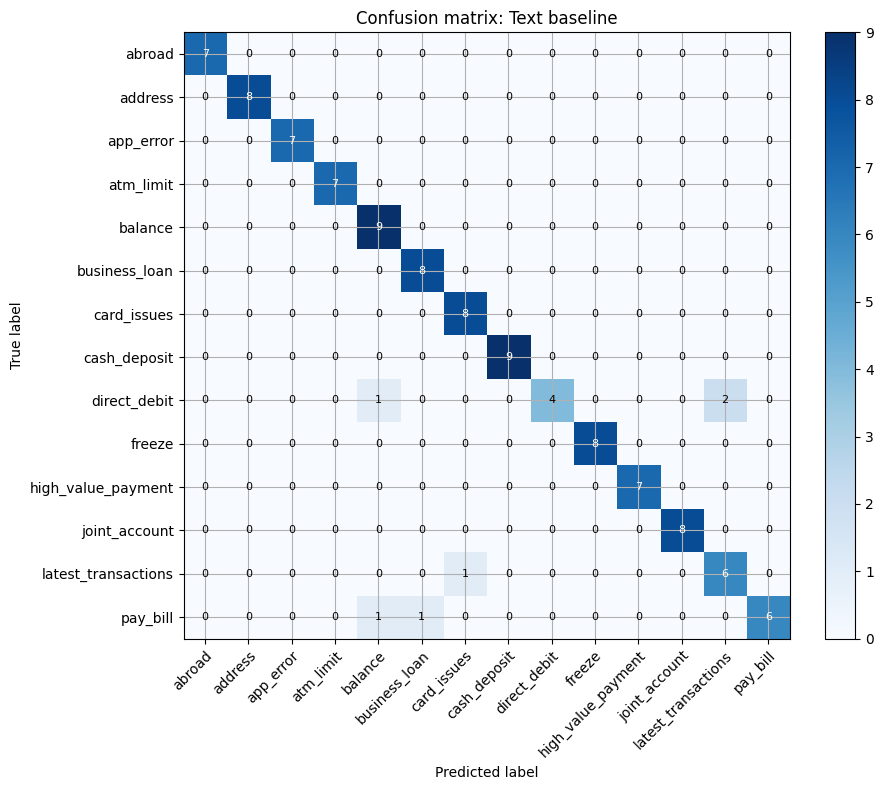

In [19]:
confusion = confusion_matrix(y_test, y_pred_text, labels=labels)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(confusion, interpolation="nearest", cmap="Blues")
ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set(
    xticks=np.arange(len(labels)),
    yticks=np.arange(len(labels)),
    xticklabels=labels,
    yticklabels=labels,
    xlabel="Predicted label",
    ylabel="True label",
    title="Confusion matrix: Text baseline",
)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

threshold = confusion.max() / 2
for row_idx in range(confusion.shape[0]):
    for col_idx in range(confusion.shape[1]):
        value = confusion[row_idx, col_idx]
        ax.text(
            col_idx,
            row_idx,
            value,
            ha="center",
            va="center",
            color="white" if value > threshold else "black",
            fontsize=8,
        )

fig.tight_layout()
plt.show()


In [21]:
def assess_feasibility(metrics: dict[str, float], thresholds: dict[str, float]) -> bool:
    """Проверяет метрики модели на соответствие приемочным порогам."""
    rows = []
    for name, threshold in thresholds.items():
        value = metrics[name]
        passed = value >= threshold
        rows.append({"metric": name, "value": value, "threshold": threshold, "passed": passed})

    display(pd.DataFrame(rows))
    print(
        "Пороги выбраны как минимальная граница feasibility для пилотного intent-сервиса: "
        "recall_weighted >= 0.70 нужен, чтобы модель не теряла большинство запросов по интентам; "
        "precision_weighted >= 0.75 ограничивает долю неверных маршрутизаций; "
        "f1_weighted >= 0.80 контролирует баланс precision/recall с учетом небольшого дисбаланса классов."
    )


_ = assess_feasibility(text_metrics, THRESHOLDS)


,metric,value,threshold,passed
0,recall_weighted,0.944444,0.70,True
1,precision_weighted,0.952184,0.75,True
2,f1_weighted,0.941730,0.80,True


Пороги выбраны как минимальная граница feasibility для пилотного intent-сервиса: recall_weighted >= 0.70 нужен, чтобы модель не теряла большинство запросов по интентам; precision_weighted >= 0.75 ограничивает долю неверных маршрутизаций; f1_weighted >= 0.80 контролирует баланс precision/recall с учетом небольшого дисбаланса классов.


Пороги в `THRESHOLDS` - это нижняя граница применимости, а не production-SLA. `recall_weighted = 0.70` допускает пилотную проверку, но защищает от модели, которая теряет значимую долю запросов; `precision_weighted = 0.75` ограничивает неверную маршрутизацию интентов; `f1_weighted = 0.80` проверяет баланс precision/recall с учетом распределения классов. Baseline заметно выше этих значений, поэтому его можно рассматривать как рабочий вариант для дальнейшей интеграции.


In [22]:
def show_text_examples(model: Pipeline, texts: list[str], labels_true: list[str], n: int = 5) -> None:
    """Показывает случайные тексты из holdout с предсказанными метками и уверенностью."""
    rng = np.random.RandomState(RANDOM_STATE)
    indices = rng.choice(len(texts), size=min(n, len(texts)), replace=False)
    probabilities = model.predict_proba([texts[idx] for idx in indices])
    rows = []
    for row_idx, idx in enumerate(indices):
        best_idx = int(np.argmax(probabilities[row_idx]))
        rows.append(
            {
                "text": texts[idx],
                "true_label": labels_true[idx],
                "pred_label": model.classes_[best_idx],
                "score": probabilities[row_idx][best_idx],
            }
        )
    display(pd.DataFrame(rows))


show_text_examples(text_model, X_test, y_test, n=5)

,text,true_label,pred_label,score
0,я пытаюсь совершить крупный платёж через интер...,high_value_payment,high_value_payment,0.632207
1,Здравствуйте пожалуйста заблокируйте мою карту...,freeze,freeze,0.603941
2,покажите мне мои последние транзакции Я не уве...,latest_transactions,latest_transactions,0.715047
3,Здравствуйте Я хочу узнать что баланс счёта,balance,balance,0.529506
4,Покажи мне баланс моего счёта,balance,balance,0.637176


## 4. Сохранение модели


In [23]:
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
metadata = {
    "dataset_name": DATASET_NAME,
    "language_config": LANGUAGE_CONFIG,
    "text_column": text_col,
    "label_column": label_col,
    "test_size": TEST_SIZE,
    "random_state": RANDOM_STATE,
    "labels": labels,
    "metrics": text_metrics,
}
joblib.dump({"model": text_model, "metadata": metadata}, MODEL_PATH)
print("Saved:", MODEL_PATH.resolve())

Saved: /kaggle/working/models/intent_classifier.joblib


## 5. Аудио pipeline

ASR-модель: `openai/whisper-small`.

Обоснование выбора: Whisper является multilingual ASR, поддерживает русский язык и подходит для коротких пользовательских запросов. Версия `small` дает разумный баланс качества и скорости на RTX 3090. Качество ASR оценивается через `WER` и `CER`, а влияние на задачу - через intent-метрики на ASR-транскриптах.

### 5.1. Сравнение ASR-моделей по открытым benchmark

Ниже внешний контекст по открытым benchmark. Метрика `WER` ниже - лучше. Для русского языка берем таблицы из Appendix D статьи Whisper: `Common Voice 9` и `FLEURS`. Размеры, VRAM и относительная скорость - из официального README `openai/whisper`.

| Модель | Params | VRAM | Отн. скорость | Common Voice 9 ru WER, % | FLEURS ru WER, % |
|---|---:|---:|---:|---:|---:|
| `openai/whisper-tiny` | 39M | ~1 GB | ~10x | 40.6 | 31.1 |
| `openai/whisper-base` | 74M | ~1 GB | ~7x | 28.8 | 20.5 |
| `openai/whisper-small` | 244M | ~2 GB | ~4x | 15.0 | 11.4 |
| `openai/whisper-medium` | 769M | ~5 GB | ~2x | 9.3 | 7.2 |
| `openai/whisper-large` | 1550M | ~10 GB | 1x | 8.2 | 6.4 |
| `openai/whisper-large-v2` | 1550M | ~10 GB | 1x | 7.1 | 5.6 |

Вывод: `whisper-large-v2` лучше по WER, но тяжелее и медленнее. Для тестового сервиса выбран `whisper-small`: он заметно лучше `tiny/base` на русском, но требует около `~2 GB` VRAM и остается достаточно быстрым для коротких пользовательских аудио.

Для общего контекста по другим семействам ASR в статье Whisper также приводится multilingual-сравнение: `XLS-R (1B)` имеет `WER 10.9` на MLS и `10.6` на VoxPopuli, `mSLAM-CTC (2B)` - `9.7` и `9.1`, `Maestro` - `8.1` на VoxPopuli, а zero-shot Whisper - `7.3` на MLS и `13.6` на VoxPopuli. Эти цифры не русскоязычный MINDS-14 и не полностью заменяют локальную оценку, но показывают, что выбор ASR зависит от языка, домена и latency.


In [24]:
import torch
from transformers import AutoModelForSpeechSeq2Seq, AutoProcessor


def load_asr_model(model_name: str):
    """Загружает модель Whisper ASR и процессор на лучшее доступное устройство."""
    device = "cuda:0" if torch.cuda.is_available() else "cpu"
    torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32
    model_kwargs = {
        "low_cpu_mem_usage": True,
        "use_safetensors": True,
    }
    try:
        model = AutoModelForSpeechSeq2Seq.from_pretrained(
            model_name,
            dtype=torch_dtype,
            **model_kwargs,
        )
    except TypeError:
        model = AutoModelForSpeechSeq2Seq.from_pretrained(
            model_name,
            torch_dtype=torch_dtype,
            **model_kwargs,
        )
    model.to(device)
    processor = AutoProcessor.from_pretrained(model_name)
    return model, processor, device, torch_dtype


asr_model, asr_processor, asr_device, asr_torch_dtype = load_asr_model(ASR_MODEL_NAME)
print("ASR model:", ASR_MODEL_NAME)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

ASR model: openai/whisper-small


In [25]:
def to_mono_float32(array: Any) -> np.ndarray:
    """Преобразует аудиосэмплы в моноформат numpy float32."""
    if hasattr(array, "detach"):
        array = array.detach().cpu().numpy()
    audio_array = np.asarray(array)
    if audio_array.ndim == 2:
        if audio_array.shape[0] <= audio_array.shape[1]:
            audio_array = audio_array.mean(axis=0)
        else:
            audio_array = audio_array.mean(axis=1)
    return audio_array.astype(np.float32)


def resample_audio(audio_array: np.ndarray, source_rate: int, target_rate: int) -> np.ndarray:
    """Передискретизирует аудиосигнал к целевой частоте ASR."""
    if source_rate == target_rate:
        return audio_array
    from math import gcd
    from scipy.signal import resample_poly

    divisor = gcd(source_rate, target_rate)
    up = target_rate // divisor
    down = source_rate // divisor
    return resample_poly(audio_array, up, down).astype(np.float32)


def extract_audio_array(audio: Any) -> tuple[np.ndarray, int]:
    """Извлекает сэмплы сигнала и частоту дискретизации из поддерживаемых аудиообъектов."""
    if isinstance(audio, dict):
        if audio.get("array") is not None and audio.get("sampling_rate") is not None:
            return to_mono_float32(audio["array"]), int(audio["sampling_rate"])
        if audio.get("path"):
            import soundfile as sf

            array, sampling_rate = sf.read(audio["path"])
            return to_mono_float32(array), int(sampling_rate)

    if hasattr(audio, "get_all_samples"):
        samples = audio.get_all_samples()
        sampling_rate = getattr(samples, "sample_rate", None) or getattr(samples, "sampling_rate", None)
        return to_mono_float32(samples.data), int(sampling_rate)

    if hasattr(audio, "array") and hasattr(audio, "sampling_rate"):
        return to_mono_float32(audio.array), int(audio.sampling_rate)

    raise TypeError(f"Unsupported audio object: {type(audio)}")


def audio_to_text(sample: dict[str, Any]) -> str:
    """Расшифровывает один аудиосэмпл MINDS-14 настроенной ASR-моделью."""
    audio = sample[audio_col]
    audio_array, sampling_rate = extract_audio_array(audio)
    target_sampling_rate = asr_processor.feature_extractor.sampling_rate
    audio_array = resample_audio(audio_array, sampling_rate, target_sampling_rate)
    inputs = asr_processor(
        audio_array,
        sampling_rate=target_sampling_rate,
        return_attention_mask=True,
        return_tensors="pt",
    )
    input_features = inputs.input_features.to(asr_device, dtype=asr_torch_dtype)
    attention_mask = inputs.attention_mask.to(asr_device) if "attention_mask" in inputs else None
    generation_kwargs = {"language": ASR_LANGUAGE, "task": ASR_TASK}
    if attention_mask is not None:
        generation_kwargs["attention_mask"] = attention_mask
    with torch.no_grad():
        predicted_ids = asr_model.generate(
            input_features,
            **generation_kwargs,
        )
    return asr_processor.batch_decode(predicted_ids, skip_special_tokens=True)[0].strip()


audio_eval_df = test_df.copy()
if ASR_EVAL_LIMIT is not None:
    audio_eval_df = audio_eval_df.sample(n=min(ASR_EVAL_LIMIT, len(audio_eval_df)), random_state=RANDOM_STATE)

source_indices = audio_eval_df["source_index"].astype(int).tolist()
base_ds_for_audio = base_ds.select(source_indices)

asr_rows = []
for (_, row), sample in zip(audio_eval_df.iterrows(), base_ds_for_audio):
    asr_rows.append(
        {
            "source_index": int(row["source_index"]),
            "reference_text": row[text_col],
            "true_label": row[label_col],
            "asr_text": audio_to_text(sample),
        }
    )

asr_df = pd.DataFrame(asr_rows)
display(asr_df.head())

A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> to see related `.generate()` flags.


,source_index,reference_text,true_label,asr_text
0,215,Здравствуйте я звоню по поводу нового бизнес к...,business_loan,"Здравствуйте, я звоню по поводу нового бизнес-..."
1,121,Добрый день Меня интересует как можно пополнит...,cash_deposit,"Добрый день! Меня интересует, как можно пополн..."
2,413,здравствуйте мне нужно срочно заблокировать карту,freeze,Здравствуйте! Мне нужно срочно заблокировать к...
3,432,Добрый день если у меня лимит на снятие,atm_limit,Добрый день. Есть ли у меня лимит на снятие?
4,14,покажите мне мои последние транзакции Я не уве...,latest_transactions,Покажите мне мои последние транзакции. Я не ув...


In [26]:
references = asr_df["reference_text"].astype(str).tolist()
hypotheses = asr_df["asr_text"].astype(str).tolist()

asr_quality = {"wer": wer(references, hypotheses), "cer": cer(references, hypotheses)}
display(pd.DataFrame([asr_quality]))


,wer,cer
0,0.439896,0.143863


In [26]:
asr_pred = text_model.predict(asr_df["asr_text"].astype(str).tolist())
asr_metrics = evaluate_classifier(
    asr_df["true_label"].astype(str).tolist(),
    asr_pred.tolist(),
    "Intent classifier on ASR transcripts",
)


Intent classifier on ASR transcripts


,accuracy,precision_weighted,recall_weighted,f1_weighted,f1_macro
0,0.953704,0.957973,0.953704,0.951323,0.951066


                     precision    recall  f1-score   support

             abroad       1.00      1.00      1.00         7
            address       1.00      1.00      1.00         8
          app_error       0.88      1.00      0.93         7
          atm_limit       1.00      1.00      1.00         7
            balance       0.90      1.00      0.95         9
      business_loan       0.89      1.00      0.94         8
        card_issues       1.00      1.00      1.00         8
       cash_deposit       1.00      1.00      1.00         9
       direct_debit       0.86      0.86      0.86         7
             freeze       1.00      1.00      1.00         8
 high_value_payment       1.00      1.00      1.00         7
      joint_account       1.00      0.88      0.93         8
latest_transactions       0.88      1.00      0.93         7
           pay_bill       1.00      0.62      0.77         8

           accuracy                           0.95       108
          macro avg   

In [26]:
comparison = pd.DataFrame(
    [
        {"setting": "original_transcription", **text_metrics},
        {"setting": "asr_transcription", **asr_metrics},
    ]
)
display(comparison)


,setting,accuracy,precision_weighted,recall_weighted,f1_weighted,f1_macro
0,original_transcription,0.944444,0.952184,0.944444,0.941730,0.940483
1,asr_transcription,0.953704,0.957973,0.953704,0.951323,0.951066


In [26]:
_ = assess_feasibility(asr_metrics, THRESHOLDS)


,metric,value,threshold,passed
0,recall_weighted,0.953704,0.70,True
1,precision_weighted,0.957973,0.75,True
2,f1_weighted,0.951323,0.80,True


Пороги выбраны как минимальная граница feasibility для пилотного intent-сервиса: recall_weighted >= 0.70 нужен, чтобы модель не теряла большинство запросов по интентам; precision_weighted >= 0.75 ограничивает долю неверных маршрутизаций; f1_weighted >= 0.80 контролирует баланс precision/recall с учетом небольшого дисбаланса классов.


In [27]:
asr_probs = text_model.predict_proba(asr_df["asr_text"].astype(str).tolist())
asr_df = asr_df.assign(
    pred_label=asr_pred,
    score=asr_probs.max(axis=1),
    is_correct=asr_df["true_label"].astype(str).values == asr_pred,
)


In [27]:
print("5 хороших примеров")
display(asr_df[asr_df["is_correct"]].head(5))


5 хороших примеров


,source_index,reference_text,true_label,asr_text,pred_label,score,is_correct
0,215,Здравствуйте я звоню по поводу нового бизнес к...,business_loan,"Здравствуйте, я звоню по поводу нового бизнес-...",business_loan,0.549022,True
1,121,Добрый день Меня интересует как можно пополнит...,cash_deposit,"Добрый день! Меня интересует, как можно пополн...",cash_deposit,0.174910,True
2,413,здравствуйте мне нужно срочно заблокировать карту,freeze,Здравствуйте! Мне нужно срочно заблокировать к...,freeze,0.728860,True
3,432,Добрый день если у меня лимит на снятие,atm_limit,Добрый день. Есть ли у меня лимит на снятие?,atm_limit,0.299129,True
4,14,покажите мне мои последние транзакции Я не уве...,latest_transactions,Покажите мне мои последние транзакции. Я не ув...,latest_transactions,0.728677,True


In [27]:
print("5 плохих примеров")
display(asr_df[~asr_df["is_correct"]].head(5))


5 плохих примеров


,source_index,reference_text,true_label,asr_text,pred_label,score,is_correct
32,315,оплата счёта,pay_bill,А плата счета.,balance,0.127272,False
39,248,сравнить насчёт Могу ли я ничего твоего парня ...,joint_account,"Как ни заготовки, вместе еще одного делия и не...",app_error,0.473123,False
49,341,Добрый день А скажите пожалуйста Я хочу внести...,pay_bill,"Добрый день. Скажите, пожалуйста, я хочу унест...",business_loan,0.123879,False
71,55,Как я могу получить полную выписку о транзакци...,direct_debit,Как я могу получить полную выписку о транзакци...,latest_transactions,0.288757,False
76,338,Доброе утро У меня есть два неоплаченных счёта...,pay_bill,Доброе утро! У меня есть звание оплаченных сче...,direct_debit,0.135756,False


## 6. LoRA


Для LoRA-эксперимента за основу взята `DeepPavlov/rubert-base-cased`: это русскоязычный BERT, поэтому он лучше соответствует коротким русским фразам MINDS-14, чем общий multilingual-backbone. LoRA выбрана вместо полного fine-tuning, потому что датасет небольшой, а адаптеры обучают только компактные низкоранговые добавки к слоям attention/dense: это снижает число обучаемых параметров, требования к памяти и риск переобучения. В обучении тексты токенизируются до `max_length=160`, ставится классификационная голова на 14 интентов, адаптеры `r=16`, `lora_alpha=32`, `lora_dropout=0.05`, а лучший чекпоинт выбирается по `f1_weighted`, потому что классы немного несбалансированы.


In [28]:
from datasets import Dataset as HFDataset
from peft import LoraConfig, TaskType, get_peft_model
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

BACKBONE_NAME = "DeepPavlov/rubert-base-cased"
label_list = sorted(train_df[label_col].astype(str).unique().tolist())
label2id = {label: idx for idx, label in enumerate(label_list)}
id2label = {idx: label for label, idx in label2id.items()}

train_hf = HFDataset.from_pandas(train_df[[text_col, label_col]].reset_index(drop=True))
test_hf = HFDataset.from_pandas(test_df[[text_col, label_col]].reset_index(drop=True))
train_hf = train_hf.map(lambda row: {"labels": label2id[str(row[label_col])]})
test_hf = test_hf.map(lambda row: {"labels": label2id[str(row[label_col])]})

tokenizer = AutoTokenizer.from_pretrained(BACKBONE_NAME, use_fast=True)

def tokenize(batch):
    """Токенизирует текстовые батчи для дообучения трансформера."""
    return tokenizer(batch[text_col], truncation=True, max_length=160)

train_tok = train_hf.map(tokenize, batched=True)
test_tok = test_hf.map(tokenize, batched=True)

keep_columns = ["input_ids", "attention_mask", "labels"]
if "token_type_ids" in train_tok.column_names:
    keep_columns.append("token_type_ids")
train_tok = train_tok.remove_columns([col for col in train_tok.column_names if col not in keep_columns])
test_tok = test_tok.remove_columns([col for col in test_tok.column_names if col not in keep_columns])

transformer_model = AutoModelForSequenceClassification.from_pretrained(
    BACKBONE_NAME,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id,
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["query", "key", "value", "dense"],
)
transformer_model = get_peft_model(transformer_model, lora_config)

def compute_metrics(eval_pred):
    """Считает метрики классификации для валидационных предсказаний LoRA."""
    logits, true_ids = eval_pred
    pred_ids = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(true_ids, pred_ids),
        "precision_weighted": precision_score(true_ids, pred_ids, average="weighted", zero_division=0),
        "recall_weighted": recall_score(true_ids, pred_ids, average="weighted", zero_division=0),
        "f1_weighted": f1_score(true_ids, pred_ids, average="weighted", zero_division=0),
        "f1_macro": f1_score(true_ids, pred_ids, average="macro", zero_division=0),
    }

import inspect

training_args_kwargs = {
    "output_dir": "models/lora-rubert-tiny2",
    "learning_rate": 5e-4,
    "per_device_train_batch_size": 8,
    "per_device_eval_batch_size": 32,
    "num_train_epochs": 12,
    "save_strategy": "epoch",
    "load_best_model_at_end": True,
    "metric_for_best_model": "f1_weighted",
    "logging_steps": 10,
    "warmup_ratio": 0.10,
    "weight_decay": 0.01,
    "gradient_accumulation_steps": 2,
    "report_to": "none",
}
training_args_params = inspect.signature(TrainingArguments.__init__).parameters
if "evaluation_strategy" in training_args_params:
    training_args_kwargs["evaluation_strategy"] = "epoch"
else:
    training_args_kwargs["eval_strategy"] = "epoch"

training_args = TrainingArguments(**training_args_kwargs)

trainer_kwargs = {
    "model": transformer_model,
    "args": training_args,
    "train_dataset": train_tok,
    "eval_dataset": test_tok,
    "data_collator": DataCollatorWithPadding(tokenizer=tokenizer),
    "compute_metrics": compute_metrics,
}
trainer_params = inspect.signature(Trainer.__init__).parameters
if "tokenizer" in trainer_params:
    trainer_kwargs["tokenizer"] = tokenizer
else:
    trainer_kwargs["processing_class"] = tokenizer

trainer = Trainer(**trainer_kwargs)


Map:   0%|          | 0/431 [00:00<?, ? examples/s]

Map:   0%|          | 0/108 [00:00<?, ? examples/s]

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/108 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you

In [28]:
trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,F1 Macro
1,10.569473,5.169080,0.175926,0.151422,0.175926,0.111974,0.112752
2,9.830260,4.200773,0.222222,0.165498,0.222222,0.118478,0.115708
3,7.578844,3.053541,0.592593,0.743792,0.592593,0.572558,0.566299
4,5.111765,1.533536,0.898148,0.919332,0.898148,0.896124,0.891428
5,1.634677,0.718119,0.935185,0.940715,0.935185,0.933738,0.932293
6,0.693341,0.427924,0.935185,0.941193,0.935185,0.933404,0.931308
7,0.328713,0.515866,0.944444,0.952184,0.944444,0.941113,0.940483
8,0.074301,0.376495,0.953704,0.956533,0.953704,0.952166,0.950623
9,0.041229,0.502410,0.953704,0.961034,0.953704,0.952540,0.951035
10,0.019333,0.571915,0.953704,0.961034,0.953704,0.952540,0.951035


In [28]:
lora_eval = trainer.evaluate()
display(pd.DataFrame([lora_eval]))


,eval_loss,eval_accuracy,eval_precision_weighted,eval_recall_weighted,eval_f1_weighted,eval_f1_macro,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch
0,0.50241,0.953704,0.961034,0.953704,0.95254,0.951035,0.5511,195.954,3.629,12.0


In [28]:
logits = trainer.predict(test_tok).predictions
lora_pred_ids = np.argmax(logits, axis=1)
y_true_ids = test_df[label_col].astype(str).map(label2id).to_numpy()
print(classification_report(y_true_ids, lora_pred_ids, target_names=label_list, zero_division=0))

                     precision    recall  f1-score   support

             abroad       1.00      1.00      1.00         7
            address       1.00      1.00      1.00         8
          app_error       1.00      1.00      1.00         7
          atm_limit       1.00      1.00      1.00         7
            balance       1.00      1.00      1.00         9
      business_loan       0.89      1.00      0.94         8
        card_issues       1.00      0.88      0.93         8
       cash_deposit       1.00      1.00      1.00         9
       direct_debit       1.00      0.71      0.83         7
             freeze       1.00      1.00      1.00         8
 high_value_payment       0.88      1.00      0.93         7
      joint_account       0.89      1.00      0.94         8
latest_transactions       0.78      1.00      0.88         7
           pay_bill       1.00      0.75      0.86         8

           accuracy                           0.95       108
          macro avg   

LoRA имеет качество, сопоставимое с основным пайплайном: accuracy = 0.954, f1_weighted = 0.953, f1_macro = 0.951. При этом TF-IDF + Logistic Regression остается более простым и легким решением, а LoRA можно рассматривать как более тяжелую альтернативу с небольшим выигрышем в качестве.

## 7. Общий вывод

Итоговый пайплайн: для текстового запроса используется TF-IDF по word/char n-граммам и логистическая регрессия, а для аудио сначала строится транскрипция через Whisper ASR и затем применяется тот же текстовый классификатор.



| Сценарий | accuracy | precision_weighted | recall_weighted | f1_weighted | f1_macro |
|---|---:|---:|---:|---:|---:|
| Текстовый baseline на holdout | 0.944 | 0.952 | 0.944 | 0.942 | 0.940 |
| Классификатор на ASR-транскриптах | 0.954 | 0.958 | 0.954 | 0.951 | 0.951 |
